In [10]:
import pandas as pd

In [11]:
import numpy as np

In [12]:
from sklearn.datasets import fetch_california_housing

In [13]:
housing=fetch_california_housing()


In [14]:
df=pd.DataFrame(
    housing.data,
    columns=housing.feature_names
)

In [18]:
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
dtypes: float64(8)
memory usage: 1.3 MB


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [20]:
df['Price']=housing.target
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [22]:
df.shape

(20640, 9)

In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
 8   Price       20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [24]:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [28]:
df.isnull().sum()
df.duplicated().sum()

np.int64(0)

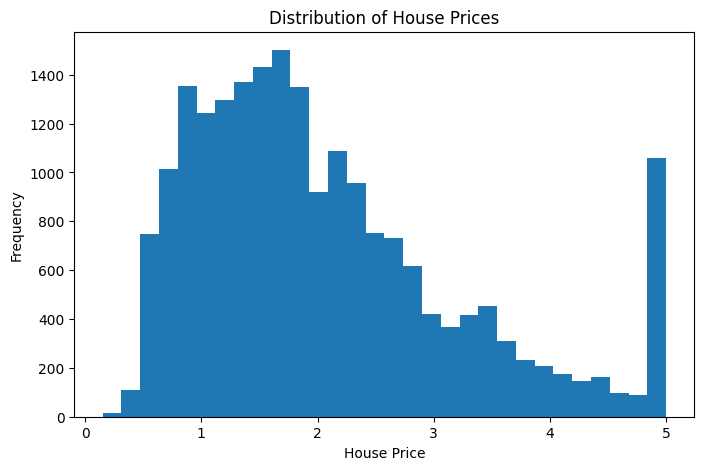

In [31]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))
plt.hist(df['Price'],bins=30)
plt.xlabel("House Price")
plt.ylabel("Frequency")
plt.title("Distribution of House Prices")
plt.show()

In [32]:
corr=df.corr()
corr['Price'].sort_values(ascending=False)

,Price
Price,1.000000
MedInc,0.688075
AveRooms,0.151948
HouseAge,0.105623
AveOccup,-0.023737
Population,-0.024650
Longitude,-0.045967
AveBedrms,-0.046701
Latitude,-0.144160


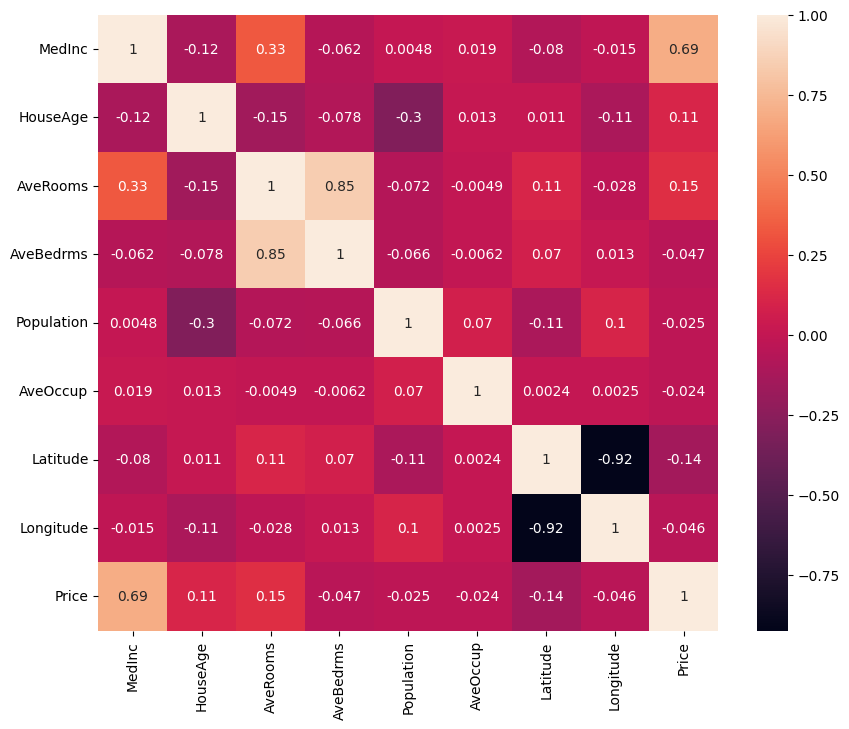

In [33]:
import seaborn as sns

plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True)
plt.show()

In [34]:
from sklearn.model_selection import train_test_split
X=df.drop('Price',axis=1)
y=df['Price']
X_train,X_test,y_train,y_test=train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


In [35]:
from sklearn.linear_model import LinearRegression
model=LinearRegression()
model.fit(X_train,y_train)

LinearRegression()

In [36]:
predictions=model.predict(X_test)

In [37]:
from sklearn.metrics import r2_score
score=r2_score(y_test,predictions)
print(score)


0.5757877060324508


In [38]:
from sklearn.metrics import(
    mean_absolute_error,
    mean_squared_error,

)


In [39]:
mae = mean_absolute_error(y_test, predictions)
mse = mean_squared_error(y_test, predictions)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, predictions)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R²  :", r2)

MAE : 0.5332001304956553
MSE : 0.5558915986952444
RMSE: 0.7455813830127764
R²  : 0.5757877060324508


In [41]:
comparison=pd.DataFrame({
    "Actual":y_test,
    "Predicted":predictions
})
comparison.head(10)

,Actual,Predicted
20046,0.47700,0.719123
3024,0.45800,1.764017
15663,5.00001,2.709659
20484,2.18600,2.838926
9814,2.78000,2.604657
13311,1.58700,2.011754
7113,1.98200,2.645500
7668,1.57500,2.168755
18246,3.40000,2.740746
5723,4.46600,3.915615


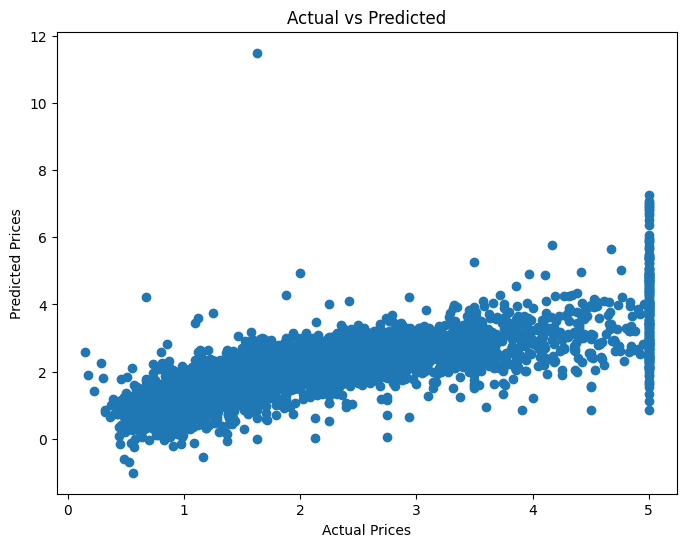

In [44]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, predictions)

plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted")

plt.show()

In [45]:
from sklearn.tree import DecisionTreeRegressor

tree = DecisionTreeRegressor(random_state=42)

tree.fit(X_train, y_train)

tree_predictions = tree.predict(X_test)
print(r2_score(y_test, tree_predictions))

0.622075845135081


In [46]:
from sklearn.ensemble import RandomForestRegressor

forest = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

forest.fit(X_train, y_train)

forest_predictions = forest.predict(X_test)
print(r2_score(y_test, forest_predictions))

0.8051230593157366


In [47]:
from xgboost import XGBRegressor
xgb = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=42
)

xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)
print(r2_score(y_test, y_pred_xgb))

0.8286517374329023


**Comparison of models**

In [49]:
Results=pd.DataFrame({

        "models":['Linear Regression','Decision Tree','Random Forest','XGBoost'],
        "R2 Score":[score,r2_score(y_test, tree_predictions),r2_score(y_test, forest_predictions),r2_score(y_test, y_pred_xgb)]
    }

)
print(Results)

              models  R2 Score
0  Linear Regression  0.575788
1      Decision Tree  0.622076
2      Random Forest  0.805123
3            XGBoost  0.828652


# **Feature Engeeniring**

In [51]:
importance=pd.DataFrame(
    {
        "Features":X.columns,
        "Importance":forest.feature_importances_
    }

)
importance.sort_values(by='Importance',ascending=False)
print(importance)

     Features  Importance
0      MedInc    0.524871
1    HouseAge    0.054593
2    AveRooms    0.044272
3   AveBedrms    0.029606
4  Population    0.030650
5    AveOccup    0.138443
6    Latitude    0.088936
7   Longitude    0.088629


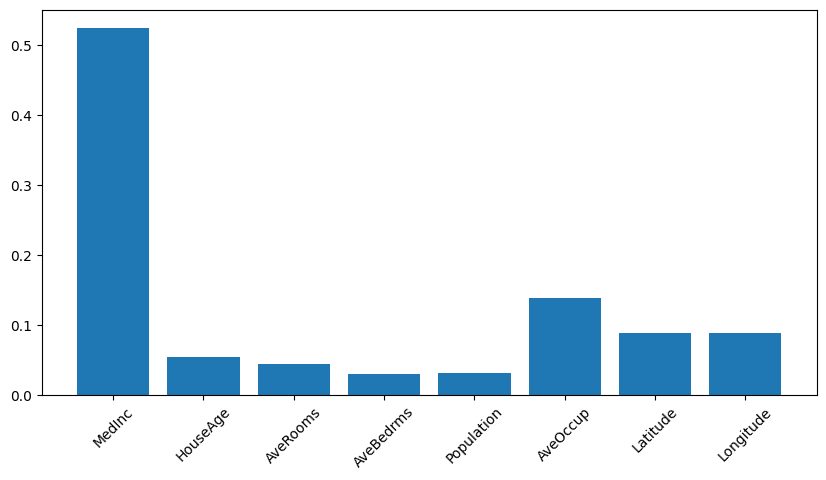

In [53]:
plt.figure(figsize=(10,5))

plt.bar(
    importance["Features"],
    importance["Importance"]
)

plt.xticks(rotation=45)

plt.show()

# Hyperparameter Tuning
to search for better parameters instead of default ones

In [55]:
from sklearn.model_selection import GridSearchCV
params = {
    "n_estimators": [100, 200],
    "max_depth": [10, 20],
    "min_samples_split": [2, 5]
}

grid = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid=params,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

grid.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=RandomForestRegressor(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [10, 20], 'min_samples_split': [2, 5],
                         'n_estimators': [100, 200]},
             scoring='r2')

In [56]:
print(grid.best_params_)
print(grid.best_score_)

{'max_depth': 20, 'min_samples_split': 2, 'n_estimators': 200}
0.8050524232098117


In [57]:
best_model = grid.best_estimator_

best_predictions = best_model.predict(X_test)

print(r2_score(y_test, best_predictions))

0.8057153985083529


In [60]:
import joblib
import os

# Create the directory if it doesn't exist
os.makedirs('models', exist_ok=True)

joblib.dump(best_model, "models/house_price_model.pkl")

['models/house_price_model.pkl']

In [61]:
model = joblib.load("models/house_price_model.pkl")

In [62]:
house = pd.DataFrame([{
    "MedInc": 8.3,
    "HouseAge": 35,
    "AveRooms": 6,
    "AveBedrms": 1,
    "Population": 500,
    "AveOccup": 3,
    "Latitude": 37.8,
    "Longitude": -122.4
}])

prediction = model.predict(house)

print(prediction)

[4.5890697]
